# T024 · 激酶相似性：序列

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Talia B. Kimber, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Dominique Sydow, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)


## 本教程的目标

在本教程中，我们研究目标激酶的序列相似性。使用 KLIFS API 检索每种激酶的口袋序列（85 个残基）。

实现了两种相似性度量：

1. 序列一致性（Identity），即基于字符级差异的相似性。
2. 序列相似性（Substitution），即基于替换矩阵的相似性，反映氨基酸之间的相似性。

_注意_：我们关注的是正构结合位点之间的相似性；变构结合位点的相似性不在讨论范围内。


### _理论_ 部分内容

* 激酶数据集
* 激酶相似性描述符：序列
    * 一致性评分
    * 替换评分
* 从相似性矩阵到距离矩阵


### _实践_ 部分内容

* 定义目标激酶
* 从 KLIFS 检索序列
* 序列相似性
    * 一致性评分
    * 替换评分
* 激酶相似性
  * 将相似性可视化为激酶矩阵
  * 保存激酶相似性矩阵
* 激酶距离矩阵
  * 保存激酶距离矩阵


### 参考文献

* 激酶数据集：[<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629)
* KLIFS
  * KLIFS URL：https://klifs.net/
  * KLIFS 数据库：[<i>Nucleic Acid Res.</i> (2020), <b>49(D1)</b>, D562-D569](https://doi.org/10.1093/nar/gkaa895)
* 基于序列的激酶聚类：Manning *et al.* [<i>Science</i> (2002), <b>298(5600)</b>, 1912-1934](https://doi.org/10.1126/science.1075762)
* 替换矩阵：[<i>PNAS</i> (1992), <b>89(22)</b>, 10915-10919](https://doi.org/10.1073/pnas.89.22.10915)
* Biotite
    * 文档：https://www.biotite-python.org/index.html
    * [替换矩阵](https://www.biotite-python.org/latest/apidoc/biotite.sequence.align.SubstitutionMatrix.html)
* 序列标志：http://www.cbs.dtu.dk/biotools/Seq2Logo/


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 24
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 激酶数据集


我们使用 **教程 T023** 中定义的激酶选择。


### 激酶相似性描述符：序列

如前一个教程所述，序列常用于评估激酶相似性（参见 Manning *et al.* 开发的系统发育树，[<i>Science</i> (2002), <b>298(5600)</b>, 1912-1934](https://doi.org/10.1126/science.1075762)）。


在本教程中，使用 KLIFS 口袋序列主要基于两个原因：

1. 序列长度固定（85 个残基），这使得两个序列之间的成对相似性计算变得简单直接。

2. 结合口袋是作用发生的场所。当 85 个残基的序列已经包含最相关信息时，为什么要考虑整个激酶序列呢？


![序列标志](images/sequence_logo.png)

_图 1：_
序列标志展示了氨基酸结合基序和序列特征，例如氨基酸的丰/缺模式。例如，序列标志可以轻松可视化保守的 G 富集环（位置 4-9）和 DFG 基序（位置 81-83），更多详情请参见 **教程 T023**。

**可重复性说明：**
此图使用 Seq2Logo 工具生成，网址为 http://www.cbs.dtu.dk/biotools/Seq2Logo/。输入是查询激酶的 85 个残基 KLIFS 结合口袋。所有参数均使用默认值。在图形布局中，将*每行叠放数*设置为 85，*页面尺寸*设置为 1200 × 480。


我们现在描述两种比较口袋序列的方法。


#### 一致性评分（Identity score）
评估两个序列之间相似性的一种简单方法是使用所谓的一致性评分。
首先，创建一个匹配向量：它检查每个位置上两个序列的字符是否相同。如果相同，则条目设置为 1，否则为 0。

一致性评分的计算方法是：对匹配向量中的元素求和，然后除以序列长度（在 KLIFS 口袋序列的情况下为 85）。


考虑下面的一致性矩阵 I：


|       | A     | C     | D     | E     | ... |
|-------|-------|-----  |-----  |-----  |-----|
| **A** | **1** | 0     | 0     | 0     | ... |
| **C** | 0     | **1** | 0     | 0     | ... |
| **D** | 0     | 0     | **1** | 0     | ... |
| **E** | 0     | 0     | 0     | **1** | ... |
| ...   | ...   | ...   | ...   | ...   | ... |


设两个激酶 $K_i$ 和 $K_j$ 的序列长度 $M = len(K_i) = len(K_j)$。


我们使用以下公式计算激酶 $K_i$ 和 $K_j$ 之间的相似性：

$$
\text{similarity}(K_i, K_j) = \frac{1}{M} \sum_{n=1}^{M} I (K_i[n], K_j[n]),
$$

其中 $K_i[n]$ 表示激酶 $i$ 序列中第 $n$ 个位置的氨基酸。


#### 替换评分（Substitution score）
虽然一致性评分是一种简单的相似性度量方法，但它没有考虑氨基酸可能突变为另一种氨基酸的速率，而是对所有残基一视同仁。

替换评分则将氨基酸在进化过程中的变化考虑在内。它使用一个替换矩阵（substitution matrix），其中每个条目给出两个氨基酸之间的评分。
在本教程中，我们使用 BLOSUM 替换矩阵（[<i>PNAS</i> (1992), <b>89(22)</b>, 10915-10919](https://doi.org/10.1073/pnas.89.22.10915)），该矩阵在 `biotite` 中实现。


BLOSUM 替换矩阵 $SM$ 定义如下（完整矩阵将在 _实践_ 部分展示）：


|       | A     | C     | D     | E     | ... |
|-------|-------|-----  |-----  |-----  |-----|
| **A** | 4     | 0     | -2    | -1    | ... |
| **C** | 0     | 9     | -3    | -4    | ... |
| **D** | -2    | -3    | 6     | 2     | ... |
| **E** | -1    | -4    | 2     | 5     | ... |
| ...   | ...   | ...   | ...   | ...   | ... |


BLOSUM 替换矩阵是对称的，如实践部分所示。

为了方便起见，我们将使用以下公式对矩阵进行平移和重新缩放：

$$
SM' = SM - min(SM),
$$

用于平移，以及

对于所有 $x, y$：

$$
SM''(x, y) = \frac{SM'[x,y]}{\sqrt{SM'[x,x]*SM'[y,y]}},
$$

用于重新缩放，使得

$$
SM''[x, x] = 1 \text{ 对于所有 } x,
$$ 且

$$
SM''[x, y] \in [0, 1] \text{ 对于所有 } x,y.
$$


我们使用以下公式计算激酶 $K_i$ 和 $K_j$ 之间的相似性：

$$
\text{similarity}(K_i, K_j) = \frac{1}{M} \sum_{n=1}^{M} SM''\big(K_i[n], K_j[n]\big),
$$

其中 $K_i[n]$ 表示激酶 $i$ 序列中第 $n$ 个位置的氨基酸，$M = len(K_i) = len(K_j)$。


### 从相似性矩阵到距离矩阵


为了应用某些聚类算法来评估激酶之间的相似性，需要从一个距离矩阵开始。根据定义，相似性矩阵不是距离矩阵。例如，对角线元素不为零。目前，我们使用以下公式将相似性矩阵 $SM$ 映射到距离矩阵 $DM$：

$$ DM = 1-SM.$$

更多详情请参见 **教程 T028**。


## 实践


In [2]:
from pathlib import Path
import requests

import pandas as pd
import numpy as np
import seaborn as sns
import biotite.sequence.align as align

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [4]:
configs = pd.read_csv(DATA / "T023_data" / "pipeline_configs.csv")
configs = configs.set_index("variable")["default_value"]
DEMO = bool(int(configs["DEMO"]))
print(f"Run in demo mode: {DEMO}")
# NBVAL_CHECK_OUTPUT

Run in demo mode: True


### 定义目标激酶


加载 **教程 T023** 中定义的激酶选择。


In [5]:
kinase_selection_df = pd.read_csv(DATA / "T023_data" / "kinase_selection.csv")
kinase_selection_df
# NBVAL_CHECK_OUTPUT

,kinase,kinase_klifs,uniprot_id,group,full_kinase_name
0,EGFR,EGFR,P00533,TK,Epidermal growth factor receptor
1,ErbB2,ErbB2,P04626,TK,Erythroblastic leukemia viral oncogene homolog 2
2,PI3K,p110a,P42336,Atypical,Phosphatidylinositol-3-kinase
3,VEGFR2,KDR,P35968,TK,Vascular endothelial growth factor receptor 2
4,BRAF,BRAF,P15056,TKL,Rapidly accelerated fibrosarcoma isoform B
5,CDK2,CDK2,P24941,CMGC,Cyclic-dependent kinase 2
6,LCK,LCK,P06239,TK,Lymphocyte-specific protein tyrosine kinase
7,MET,MET,P08581,TK,Mesenchymal-epithelial transition factor
8,p38a,p38a,Q16539,CMGC,p38 mitogen activated protein kinase alpha


### 从 KLIFS 检索序列


我们使用 KLIFS API 检索每种激酶的 85 个残基的口袋序列。


In [6]:
def klifs_pocket_sequence(klifs_kinase_name):
    """
    使用 KLIFS API 检索口袋序列。

    Parameters
    ----------
    klifs_kinase_name : str
        目标激酶的 KLIFS 名称。

    Returns
    -------
    str :
        来自 KLIFS 的 85 个残基的口袋序列，
        如果激酶名称有效，否则返回 None。
    """
    response = requests.get(
        f"https://klifs.net/api/kinase_ID?kinase_name={klifs_kinase_name}&species=HUMAN"
    )

    if response.status_code == 200:
        return response.json()[0]["pocket"]
    else:
        print(f"KLIFS failed for kinase {klifs_kinase_name}")
        return None

我们创建一个以激酶名称为键、相应的口袋序列为值的字典。该字典将在本 notebook 中全程使用。


In [7]:
kinase_sequences_dict = {}
for kinase in kinase_selection_df["kinase_klifs"]:
    kinase_sequences_dict[kinase] = klifs_pocket_sequence(kinase)

for name, sequence in kinase_sequences_dict.items():
    print(f"{name:10}{sequence}")
# NBVAL_CHECK_OUTPUT

EGFR      KVLGSGAFGTVYKVAIKELEILDEAYVMASVDPHVCRLLGIQLITQLMPFGCLLDYVREYLEDRRLVHRDLAARNVLVITDFGLA
ErbB2     KVLGSGAFGTVYKVAIKVLEILDEAYVMAGVGPYVSRLLGIQLVTQLMPYGCLLDHVREYLEDVRLVHRDLAARNVLVITDFGLA
p110a     CRIMSSAKRPLWLIIFKNGDLRQDMLTLQIIRLRMLPYGCLVGLIEVVRSHTIMQIQCKATFI--LGIGDRHNSNIMVHIDFGHF
KDR       KPLGRGAFGQVIEVAVKMLALMSELKILIHIGLNVVNLLGAMVIVEFCKFGNLSTYLRSFLASRKCIHRDLAARNILLICDFGLA
BRAF      QRIGSGSFGTVYKVAVKMLAFKNEVGVLRKTRVNILLFMGYAIVTQWCEGSSLYHHLHIYLHAKSIIHRDLKSNNIFLIGDFGLA
CDK2      EKIGEGTYGVVYKVALKKITAIREISLLKELNPNIVKLLDVYLVFEFLH-QDLKKFMDAFCHSHRVLHRDLKPQNLLILADFGLA
LCK       ERLGAGQFGEVWMVAVKSLAFLAEANLMKQLQQRLVRLYAVYIITEYMENGSLVDFLKTFIEERNYIHRDLRAANILVIADFGLA
MET       EVIGRGHFGCVYHCAVKSLQFLTEGIIMKDFSPNVLSLLGILVVLPYMKHGDLRNFIRNYLASKKFVHRDLAARNCMLVADFGLA
p38a      SPVGSGAYGSVCAVAVKKLRTYRELRLLKHMKENVIGLLDVYLVTHLMG-ADLNNIVKCYIHSADIIHRDLKPSNLAVILDFGLA


如上单元格所示，有些序列存在缺失残基，以"-"表示。让我们将这些序列绘制为热图，以便快速目视观察保守区域。


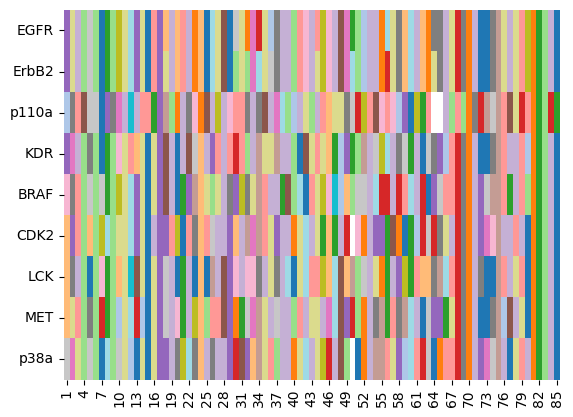

In [8]:
# 将字典转换为 DataFrame
kinase_sequences_df = pd.DataFrame(
    [list(i) for i in kinase_sequences_dict.values()],
    index=kinase_sequences_dict.keys(),
    columns=range(1, 86),
)
# Cast letters to integers (gap is set to None)
letter_to_int = {letter: ix for ix, letter in enumerate(list("ACDEFGHIKLMNPQRSTVWY"), 1)}
letter_to_int["-"] = None
kinase_sequences_int_df = kinase_sequences_df.map(lambda x: letter_to_int[x])
# Show heatmap (qualitative colormap)
ax = sns.heatmap(kinase_sequences_int_df, cmap="tab20", cbar=False)

### 序列相似性


给定两种激酶，我们创建实现一致性或替换相似性计算的函数，如_理论_部分所述。


#### 一致性评分
首先定义一个函数，逐字符比较两个序列。


In [9]:
def identity_score(sequence1, sequence2):
    """
    计算两个序列之间的逐元素二值相似性。

    Parameters
    ----------
    sequence1 : np.array
        描述第一个序列的字符数组。
    sequence2 : np.array
        描述第二个序列的字符数组。

    Returns
    -------
    np.array
        The bool array for each character.
        1 if the elements are identical,
        0 otherwise.
    """
    # True is the character is the same, False otherwise
    return np.compare_chararrays(sequence1, sequence2, cmp="==", rstrip=True)

#### 替换评分
现在定义一个更针对氨基酸分组的函数，并使用 `biotite` 库检索 BLOSUM 替换矩阵。


替换矩阵可以使用以下命令从 `biotite` 中检索：


In [10]:
substitution_matrix = align.SubstitutionMatrix.std_protein_matrix()
print(substitution_matrix)
# NBVAL_CHECK_OUTPUT

    A   C   D   E   F   G   H   I   K   L   M   N   P   Q   R   S   T   V   W   Y   B   Z   X   *
A   4   0  -2  -1  -2   0  -2  -1  -1  -1  -1  -2  -1  -1  -1   1   0   0  -3  -2  -2  -1   0  -4
C   0   9  -3  -4  -2  -3  -3  -1  -3  -1  -1  -3  -3  -3  -3  -1  -1  -1  -2  -2  -3  -3  -2  -4
D  -2  -3   6   2  -3  -1  -1  -3  -1  -4  -3   1  -1   0  -2   0  -1  -3  -4  -3   4   1  -1  -4
E  -1  -4   2   5  -3  -2   0  -3   1  -3  -2   0  -1   2   0   0  -1  -2  -3  -2   1   4  -1  -4
F  -2  -2  -3  -3   6  -3  -1   0  -3   0   0  -3  -4  -3  -3  -2  -2  -1   1   3  -3  -3  -1  -4
G   0  -3  -1  -2  -3   6  -2  -4  -2  -4  -3   0  -2  -2  -2   0  -2  -3  -2  -3  -1  -2  -1  -4
H  -2  -3  -1   0  -1  -2   8  -3  -1  -3  -2   1  -2   0   0  -1  -2  -3  -2   2   0   0  -1  -4
I  -1  -1  -3  -3   0  -4  -3   4  -3   2   1  -3  -3  -3  -3  -2  -1   3  -3  -1  -3  -3  -1  -4
K  -1  -3  -1   1  -3  -2  -1  -3   5  -2  -1   0  -1   1   2   0  -1  -2  -3  -2   0   1  -1  -4
L  -1  -1  -4  -3   

检查对称性：


In [11]:
substitution_matrix.is_symmetric()
# NBVAL_CHECK_OUTPUT

True

执行我们在_理论_部分讨论过的平移-重新缩放步骤。


In [12]:
def _translate_rescale_substitution_matrix(
    substitution_matrix=align.SubstitutionMatrix.std_protein_matrix(),
):
    """
    对替换矩阵进行平移和重新缩放。

    Parameters
    ----------
    substitution_matrix : biotite.sequence.align.SubstitutionMatrix
        特定于氨基酸的替换矩阵。
        默认为 align.SubstitutionMatrix.std_protein_matrix()
        from biotite, which represents BLOSUM62.

    Returns
    -------
    pd.DataFrame
        Translated and rescaled substitution matrix as DataFrame
        (index/columns contain letters).
    """
    # Retrieve np.array from substitution matrix
    score_matrix = substitution_matrix.score_matrix()

    # Translation of substitution matrix
    translated_matrix = score_matrix - np.min(score_matrix)

    # Rescaling
    normalized_score_matrix = np.zeros(score_matrix.shape)
    for i in range(score_matrix.shape[0]):
        for j in range(score_matrix.shape[0]):
            normalized_score_matrix[i, j] = translated_matrix[i, j] / np.sqrt(
                translated_matrix[i, i] * translated_matrix[j, j]
            )

    # Create DataFrame from matrix with letters as index/column names
    normalized_score_matrix = pd.DataFrame(
        normalized_score_matrix,
        columns=substitution_matrix.get_alphabet1(),
        index=substitution_matrix.get_alphabet1(),
    )

    # Check for symmetry
    symmetric = (
        normalized_score_matrix.values == normalized_score_matrix.values.transpose()
    ).all()
    if not symmetric:
        raise ValueError(f"Translated/rescaled matrix is not symmetric.")

    return normalized_score_matrix

让我们看一下平移和重新缩放后的替换矩阵版本。


In [13]:
_translate_rescale_substitution_matrix().style.format("{:.2f}")

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y,B,Z,X,*
A,1.00,0.39,0.22,0.35,0.22,0.45,0.20,0.38,0.35,0.38,0.35,0.22,0.32,0.35,0.35,0.62,0.47,0.50,0.09,0.21,0.25,0.38,0.82,0.00
C,0.39,1.00,0.09,0.00,0.18,0.09,0.08,0.29,0.09,0.29,0.28,0.09,0.08,0.09,0.09,0.29,0.28,0.29,0.14,0.17,0.10,0.10,0.32,0.00
D,0.22,0.09,1.00,0.63,0.10,0.30,0.27,0.11,0.32,0.00,0.11,0.50,0.29,0.42,0.21,0.45,0.32,0.11,0.00,0.10,0.89,0.56,0.55,0.00
E,0.35,0.00,0.63,1.00,0.11,0.21,0.38,0.12,0.56,0.12,0.22,0.42,0.30,0.67,0.44,0.47,0.33,0.24,0.09,0.20,0.59,0.94,0.58,0.00
F,0.22,0.18,0.10,0.11,1.00,0.10,0.27,0.45,0.11,0.45,0.42,0.10,0.00,0.11,0.11,0.22,0.21,0.34,0.41,0.67,0.11,0.11,0.55,0.00
G,0.45,0.09,0.30,0.21,0.10,1.00,0.18,0.00,0.21,0.00,0.11,0.40,0.19,0.21,0.21,0.45,0.21,0.11,0.16,0.10,0.34,0.22,0.55,0.00
H,0.20,0.08,0.27,0.38,0.27,0.18,1.00,0.10,0.29,0.10,0.19,0.46,0.17,0.38,0.38,0.31,0.19,0.10,0.15,0.52,0.41,0.41,0.50,0.00
I,0.38,0.29,0.11,0.12,0.45,0.00,0.10,1.00,0.12,0.75,0.59,0.11,0.11,0.12,0.12,0.25,0.35,0.88,0.09,0.32,0.12,0.12,0.61,0.00
K,0.35,0.09,0.32,0.56,0.11,0.21,0.29,0.12,1.00,0.24,0.33,0.42,0.30,0.56,0.67,0.47,0.33,0.24,0.09,0.20,0.47,0.59,0.58,0.00
L,0.38,0.29,0.00,0.12,0.45,0.00,0.10,0.75,0.24,1.00,0.71,0.11,0.11,0.24,0.24,0.25,0.35,0.62,0.18,0.32,0.00,0.12,0.61,0.00


定义一个计算两个序列之间替换评分的函数（将使用之前定义的函数）。


In [14]:
def substitution_score(
    sequence1, sequence2, substitution_matrix=align.SubstitutionMatrix.std_protein_matrix()
):
    """
    根据替换矩阵获取匹配评分。

    Parameters
    ----------
    sequence1 : np.array
        描述第一个序列的字符数组。
    sequence2 : np.array
        描述第二个序列的字符数组。
    substitution_matrix : biotite.sequence.align.SubstitutionMatrix
        A substitution matrix specific to amino acids.
        The default is align.SubstitutionMatrix.std_protein_matrix()
        from biotite, which represents BLOSUM62.

    Returns
    -------
    np.array
        The vector of match score
        using the normalized substitution matrix.
    """
    substitution_matrix_df = _translate_rescale_substitution_matrix(substitution_matrix)

    match_score_array = np.zeros(len(sequence1))
    for i, (character_seq1, character_seq2) in enumerate(zip(sequence1, sequence2)):
        match_score_array[i] = substitution_matrix_df.loc[character_seq1, character_seq2]
    return match_score_array

### 激酶相似性


给定两种激酶，我们创建一个函数，使用其中一种度量（一致性或替换）计算序列相似性。


In [15]:
def sequence_similarity(sequence_1, sequence_2, type_="identity"):
    """
    使用给定的度量比较两个序列。

    Parameters
    ----------
    sequence_1, sequence_2 : str
        用于比较的两个字符串序列。

    type_ : str
        用于计算相似性的度量类型。
        默认为 `identity`。

    Returns
    -------
    float :
        The similarity between the pocket sequences of the two kinases.
    """

    # Replace possible unavailable residue
    # noted in KLIFS with "-"
    # by the symbol "*" for biotite
    sequence_1 = sequence_1.replace("-", "*")
    sequence_2 = sequence_2.replace("-", "*")

    if len(sequence_1) != len(sequence_1):
        raise ValueError(f"Mismatch in sequence lengths.")
    else:
        seq_array1 = np.array(list(sequence_1))
        seq_array2 = np.array(list(sequence_2))

        if type_ == "identity":
            is_match_array = identity_score(seq_array1, seq_array2)
            similarity_normed = sum(is_match_array) / len(sequence_1)
        elif type_ == "substitution":
            match_score_array = substitution_score(seq_array1, seq_array2)
            similarity_normed = sum(match_score_array) / len(sequence_1)
        else:
            raise ValueError(f"Type {type_} not defined.")

        return similarity_normed

让我们查看两种激酶之间的序列相似性（另请参见图 2）：


In [16]:
if DEMO:
    example1 = "EGFR"
    example2 = "MET"
else:
    example1 = kinase_selection_df["kinase_klifs"][0]
    example2 = kinase_selection_df["kinase_klifs"][1]

print("The sequences are:\n")
for key in (example1, example2):
    print(f"{key:5s}: {kinase_sequences_dict[key]}")
# NBVAL_CHECK_OUTPUT

The sequences are:

EGFR : KVLGSGAFGTVYKVAIKELEILDEAYVMASVDPHVCRLLGIQLITQLMPFGCLLDYVREYLEDRRLVHRDLAARNVLVITDFGLA
MET  : EVIGRGHFGCVYHCAVKSLQFLTEGIIMKDFSPNVLSLLGILVVLPYMKHGDLRNFIRNYLASKKFVHRDLAARNCMLVADFGLA


In [17]:
example_seq_similarity = sequence_similarity(
    kinase_sequences_dict[example1], kinase_sequences_dict[example2], "identity"
)

print(
    f"Pocket sequence similarity between {example1} and {example2} kinases: "
    f"{example_seq_similarity:.2f} using identity."
)
# NBVAL_CHECK_OUTPUT

Pocket sequence similarity between EGFR and MET kinases: 0.46 using identity.


In [18]:
example_seq_similarity = sequence_similarity(
    kinase_sequences_dict[example1], kinase_sequences_dict[example2], "substitution"
)
print(
    f"Pocket sequence similarity between {example1} and {example2} kinases: "
    f"{example_seq_similarity:.2f} using substitution."
)
# NBVAL_CHECK_OUTPUT

Pocket sequence similarity between EGFR and MET kinases: 0.71 using substitution.


![EGFR 和 MET 相似性](images/sequence_similarity.png)

_图 2：_
激酶 EGFR 和 MET 的序列及序列相似性。


我们还可以查看自相似性：


In [19]:
example_seq_similarity = sequence_similarity(
    kinase_sequences_dict[example1], kinase_sequences_dict[example1], type_="identity"
)
print(
    f"Pocket sequence similarity between {example1} itself: "
    f"{example_seq_similarity:.2f} using identity."
)
# NBVAL_CHECK_OUTPUT

Pocket sequence similarity between EGFR itself: 1.00 using identity.


In [20]:
example_seq_similarity = sequence_similarity(
    kinase_sequences_dict[example1], kinase_sequences_dict[example1], type_="substitution"
)
print(
    f"Pocket sequence similarity between {example1} itself: "
    f"{example_seq_similarity:.2f} using substitution."
)
# NBVAL_CHECK_OUTPUT

Pocket sequence similarity between EGFR itself: 1.00 using substitution.


正如预期的那样，激酶与自身的相似性得分最高：


#### 将相似性可视化为激酶矩阵


In [21]:
def pairwise_kinase_similarities(kinase_sequence_dictionary, similarity_measure):
    """
    计算一组激酶之间的成对相似性。

    Parameters
    ----------
    kinase_sequence_dictionary : dict
        以激酶名称为键、激酶序列为值的字典。
    similarity_measure : str
        选择相似性度量："identity" 或 "substitution"。

    Returns
    -------
    pd.DataFrame
        All-against-all similarities between input kinases.
    """
    # Initialize matrix with 0
    kinase_similarity_matrix = np.zeros(
        (len(kinase_sequence_dictionary), len(kinase_sequence_dictionary))
    )
    # Iterate over matrix and fill with similarity values
    for i, kinase_sequence1 in enumerate(kinase_sequence_dictionary.values()):
        for j, kinase_sequence2 in enumerate(kinase_sequence_dictionary.values()):
            kinase_similarity_matrix[i, j] = sequence_similarity(
                kinase_sequence1, kinase_sequence2, similarity_measure
            )

    # Cast matrix to DataFrame
    kinase_similarity_matrix_df = pd.DataFrame(
        data=kinase_similarity_matrix,
        index=kinase_sequences_dict.keys(),
        columns=kinase_sequences_dict.keys(),
    )
    kinase_similarity_matrix_df.index.name = None
    kinase_similarity_matrix_df.columns.name = None

    # Check for symmetry
    symmetric = (
        kinase_similarity_matrix_df.values == kinase_similarity_matrix_df.values.transpose()
    ).all()
    if not symmetric:
        raise ValueError(f"Matrix is not symmetric.")

    return kinase_similarity_matrix_df

我们使用一致性和替换方法可视化相似性矩阵：


##### 激酶相似性矩阵：一致性


In [22]:
kinase_similarity_matrix_identity_df = pairwise_kinase_similarities(
    kinase_sequences_dict, similarity_measure="identity"
)
kinase_similarity_matrix_identity_df
# NBVAL_CHECK_OUTPUT

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,1.000000,0.894118,0.117647,0.470588,0.376471,0.317647,0.447059,0.458824,0.388235
ErbB2,0.894118,1.000000,0.117647,0.435294,0.400000,0.329412,0.423529,0.470588,0.400000
p110a,0.117647,0.117647,1.000000,0.152941,0.152941,0.105882,0.141176,0.105882,0.141176
KDR,0.470588,0.435294,0.152941,1.000000,0.400000,0.341176,0.435294,0.470588,0.388235
BRAF,0.376471,0.400000,0.152941,0.400000,1.000000,0.329412,0.388235,0.376471,0.376471
CDK2,0.317647,0.329412,0.105882,0.341176,0.329412,1.000000,0.376471,0.364706,0.470588
LCK,0.447059,0.423529,0.141176,0.435294,0.388235,0.376471,1.000000,0.400000,0.388235
MET,0.458824,0.470588,0.105882,0.470588,0.376471,0.364706,0.400000,1.000000,0.364706
p38a,0.388235,0.400000,0.141176,0.388235,0.376471,0.470588,0.388235,0.364706,1.000000


In [23]:
# Show matrix with background gradient
cm = sns.light_palette("green", as_cmap=True)
kinase_similarity_matrix_identity_df.style.background_gradient(cmap=cm).format("{:.3f}")

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,1.000,0.894,0.118,0.471,0.376,0.318,0.447,0.459,0.388
ErbB2,0.894,1.000,0.118,0.435,0.400,0.329,0.424,0.471,0.400
p110a,0.118,0.118,1.000,0.153,0.153,0.106,0.141,0.106,0.141
KDR,0.471,0.435,0.153,1.000,0.400,0.341,0.435,0.471,0.388
BRAF,0.376,0.400,0.153,0.400,1.000,0.329,0.388,0.376,0.376
CDK2,0.318,0.329,0.106,0.341,0.329,1.000,0.376,0.365,0.471
LCK,0.447,0.424,0.141,0.435,0.388,0.376,1.000,0.400,0.388
MET,0.459,0.471,0.106,0.471,0.376,0.365,0.400,1.000,0.365
p38a,0.388,0.400,0.141,0.388,0.376,0.471,0.388,0.365,1.000


##### 激酶相似性矩阵：替换


In [24]:
kinase_similarity_matrix_substitution_df = pairwise_kinase_similarities(
    kinase_sequences_dict, similarity_measure="substitution"
)
kinase_similarity_matrix_substitution_df
# NBVAL_CHECK_OUTPUT

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,1.000000,0.940963,0.427062,0.716047,0.655028,0.648447,0.711321,0.711258,0.644644
ErbB2,0.940963,1.000000,0.413638,0.702118,0.654600,0.630308,0.685075,0.697967,0.635173
p110a,0.427062,0.413638,1.000000,0.422705,0.436459,0.423994,0.451336,0.393699,0.431194
KDR,0.716047,0.702118,0.422705,1.000000,0.671268,0.653379,0.687648,0.713806,0.653444
BRAF,0.655028,0.654600,0.436459,0.671268,1.000000,0.646755,0.672933,0.638158,0.637912
CDK2,0.648447,0.630308,0.423994,0.653379,0.646755,1.000000,0.681253,0.656025,0.723093
LCK,0.711321,0.685075,0.451336,0.687648,0.672933,0.681253,1.000000,0.690879,0.662581
MET,0.711258,0.697967,0.393699,0.713806,0.638158,0.656025,0.690879,1.000000,0.629355
p38a,0.644644,0.635173,0.431194,0.653444,0.637912,0.723093,0.662581,0.629355,1.000000


In [25]:
# Show matrix with background gradient
cm = sns.light_palette("green", as_cmap=True)
kinase_similarity_matrix_substitution_df.style.background_gradient(cmap=cm).format("{:.3f}")

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,1.000,0.941,0.427,0.716,0.655,0.648,0.711,0.711,0.645
ErbB2,0.941,1.000,0.414,0.702,0.655,0.630,0.685,0.698,0.635
p110a,0.427,0.414,1.000,0.423,0.436,0.424,0.451,0.394,0.431
KDR,0.716,0.702,0.423,1.000,0.671,0.653,0.688,0.714,0.653
BRAF,0.655,0.655,0.436,0.671,1.000,0.647,0.673,0.638,0.638
CDK2,0.648,0.630,0.424,0.653,0.647,1.000,0.681,0.656,0.723
LCK,0.711,0.685,0.451,0.688,0.673,0.681,1.000,0.691,0.663
MET,0.711,0.698,0.394,0.714,0.638,0.656,0.691,1.000,0.629
p38a,0.645,0.635,0.431,0.653,0.638,0.723,0.663,0.629,1.000


当我们比较基于一致性评分和替换评分计算的矩阵时，整体模式是相似的，但使用替换评分的值普遍更高。

_注意_：对于所有下游分析，我们将只考虑基于替换矩阵计算的激酶相似性矩阵。


In [26]:
kinase_similarity_matrix_df = kinase_similarity_matrix_substitution_df

#### 保存激酶相似性矩阵


In [27]:
file_name = f"kinase_similarity_matrix.csv"
kinase_similarity_matrix_df.to_csv(DATA / file_name)

### 激酶距离矩阵


由于所有条目的值都在 0 和 1 之间，相似性矩阵 $SM$ 被映射到距离矩阵：


In [28]:
print(
    f"The values of the similarity matrix lie between: "
    f"{kinase_similarity_matrix_df.min().min():.2f}"
    f" and {kinase_similarity_matrix_df.max().max():.2f}"
)
# NBVAL_CHECK_OUTPUT

The values of the similarity matrix lie between: 0.39 and 1.00


In [29]:
kinase_distance_matrix_df = 1 - kinase_similarity_matrix_df

In [30]:
kinase_distance_matrix_df.style.background_gradient(cmap=cm).format("{:.3f}")

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,0.000,0.059,0.573,0.284,0.345,0.352,0.289,0.289,0.355
ErbB2,0.059,0.000,0.586,0.298,0.345,0.370,0.315,0.302,0.365
p110a,0.573,0.586,0.000,0.577,0.564,0.576,0.549,0.606,0.569
KDR,0.284,0.298,0.577,0.000,0.329,0.347,0.312,0.286,0.347
BRAF,0.345,0.345,0.564,0.329,0.000,0.353,0.327,0.362,0.362
CDK2,0.352,0.370,0.576,0.347,0.353,0.000,0.319,0.344,0.277
LCK,0.289,0.315,0.549,0.312,0.327,0.319,0.000,0.309,0.337
MET,0.289,0.302,0.606,0.286,0.362,0.344,0.309,0.000,0.371
p38a,0.355,0.365,0.569,0.347,0.362,0.277,0.337,0.371,0.000


#### 保存激酶距离矩阵


In [31]:
file_name = f"kinase_distance_matrix.csv"
kinase_distance_matrix_df.to_csv(DATA / file_name)

## 讨论

在本教程中，我们研究了如何使用序列来衡量激酶之间的相似性。重点放在口袋序列上，该序列从 KLIFS 获取。序列相似性可以使用两种评分来评估：1. 一致性评分，对所有氨基酸一视同仁；2. 替换评分，考虑了残基在进化过程中的变化速率。

上面的激酶相似性矩阵将在 **教程 T028** 中重新加载，届时我们将从不同角度比较激酶相似性，包括本教程中讨论的口袋序列角度。


## 测验

1. 是否应该使用完整的激酶序列代替口袋序列？
2. 基于一致性的相似性在突变情况下表现如何？
3. 基于一致性的相似性与基于替换的相似性相比如何？
